In [63]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow 
from tensorflow import keras 
from keras.layers import Dense, Dropout 
from keras.optimizers import SGD,Adam,Adagrad, RMSprop 
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential 

In [64]:
df = pd.read_csv('placement.csv')

In [65]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [98]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]
X.head()

,cgpa,resume_score
0,8.14,6.52
1,6.17,5.17
2,8.27,8.86
3,6.88,7.27
4,7.52,7.30


In [99]:
X.shape

(100, 2)

In [100]:
X['ip'] = np.random.choice([0,1], size=X.shape[0],p=[0.6,0.4])

In [101]:
X['ip'].value_counts()

ip
0    62
1    38
Name: count, dtype: int64

In [103]:
X.sample(10)

,cgpa,resume_score,ip
69,8.06,9.06,1
80,7.83,7.70,0
26,6.27,6.47,1
41,8.68,5.15,0
78,5.79,5.66,0
53,6.00,7.16,0
86,6.18,5.76,0
82,7.92,6.06,1
32,5.87,7.96,0
2,8.27,8.86,0


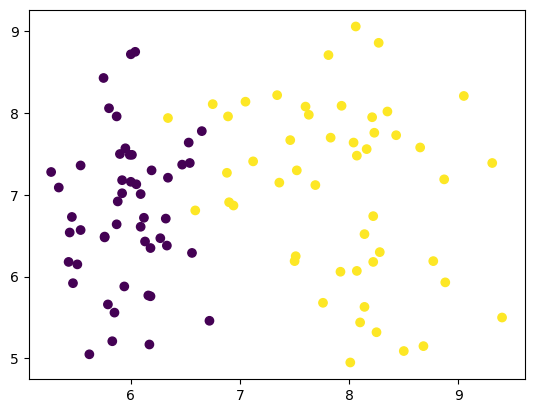

In [67]:
plt.scatter(x=X.iloc[:,0],y=X.iloc[:,1],c=y)

In [68]:
model = Sequential()

model.add(Dense(16, input_dim=2, activation='relu'))
model.add(Dense(26,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
optimizer1 = SGD(learning_rate=0.01,momentum=0.0,nesterov=False, name="SGD") # Vanilla Gradient Descent
optimizer2 = SGD(learning_rate=0.01,momentum=0.9,nesterov=False, name="SGD") # SGD with momentum
optimizer3 = SGD(learning_rate=0.01,momentum=0.9,nesterov=True, name="SGD") # NAG


In [70]:
model.compile(optimizer=optimizer1,loss='binary_crossentropy',metrics=['accuracy'])

hist1 = model.fit(X,y,validation_split=0.2, epochs=200, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


<Axes: >

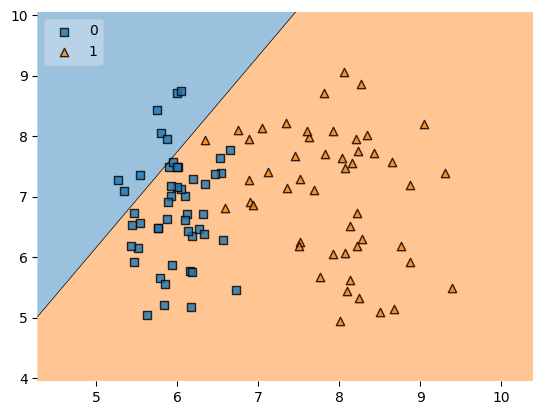

In [71]:
from mlxtend.plotting import plot_decision_regions 


plot_decision_regions(X.values,y.values,clf=model,legend=2)

In [72]:

model1 = Sequential()

model1.add(Dense(16, input_dim=2, activation='relu'))
model1.add(Dense(16,activation='relu'))
model1.add(Dense(16,activation='relu'))
model1.add(Dense(16,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))
model1.compile(optimizer=optimizer2,loss='binary_crossentropy',metrics=['accuracy'])# SGD with momentum
hist2 = model1.fit(X,y,validation_split=0.2, epochs=200, verbose=0)

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

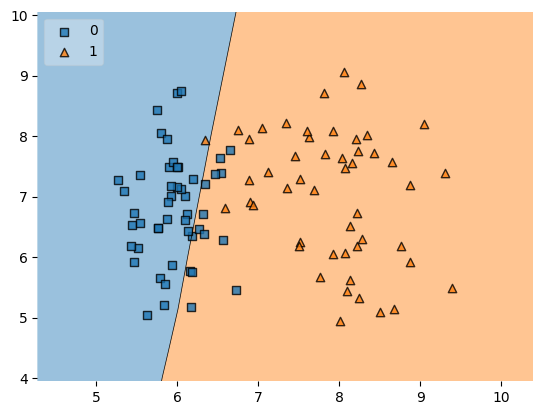

In [73]:
from mlxtend.plotting import plot_decision_regions 


plot_decision_regions(X.values,y.values,clf=model1,legend=2)

In [86]:
# Applying NAG
model2 = Sequential()

optimizer3 = SGD(learning_rate=0.01,momentum=0.9,nesterov=True, name="SGD") # NAG

model2.add(Dense(16, input_dim=2, activation='relu'))
model2.add(Dense(16,activation='relu'))
model2.add(Dense(16,activation='relu'))
model2.add(Dense(8,activation='relu'))
model2.add(Dense(4,activation='relu'))
model2.add(Dense(1,activation='sigmoid'))
model2.compile(optimizer=optimizer3,loss='binary_crossentropy',metrics=['accuracy'])

hist3 = model2.fit(X,y,validation_split=0.2, epochs=300)

Epoch 1/300


c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step - accuracy: 0.5125 - loss: 0.6750 - val_accuracy: 0.4500 - val_loss: 0.6926
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5125 - loss: 0.6582 - val_accuracy: 0.4500 - val_loss: 0.6572
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5125 - loss: 0.6479 - val_accuracy: 0.6000 - val_loss: 0.6568
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6375 - loss: 0.6507 - val_accuracy: 0.4500 - val_loss: 0.6448
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7000 - loss: 0.6331 - val_accuracy: 0.4500 - val_loss: 0.6805
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5750 - loss: 0.6340 - val_accuracy: 0.4500 - val_loss: 0.6406
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6125 - loss: 0.6049 - val_accuracy: 0.5000 - val_loss: 0.6153
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6250 - loss: 0.5975 - val_accuracy: 0.6500 - val_loss: 0.5992
Epo

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


<Axes: >

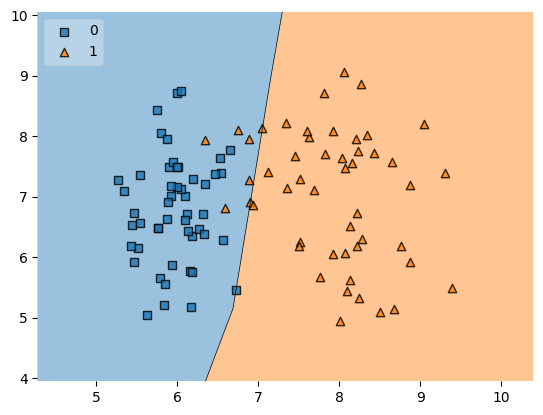

In [87]:
from mlxtend.plotting import plot_decision_regions 


plot_decision_regions(X.values,y.values,clf=model2,legend=2)